# 91. 軽量Embeddingモデル性能比較

## 目的
2025-2026年の軽量Embeddingモデルの性能を日本語・英語で評価し、ITQ-LSHとの相性を検討する。

## 評価対象モデル
| # | モデル | HF ID | パラメータ | Emb次元 |
|---|--------|--------|-----------|--------|
| 1 | EmbeddingGemma-300M | google/embeddinggemma-300m | 308M | 768 |
| 2 | Qwen3-Embedding-0.6B | Qwen/Qwen3-Embedding-0.6B | 600M | 1024 |
| 3 | Qwen3-Embedding-8B | Qwen/Qwen3-Embedding-8B | 8B | 1024 |
| 4 | BGE-M3 | BAAI/bge-m3 | ~400M | 1024 |
| 5 | PLaMo-Embedding-1B | pfnet/plamo-embedding-1b | 1B | 2048 |
| 6 | Ruri-v3-310m | cl-nagoya/ruri-v3-310m | 310M | 768 |
| 7 | multilingual-e5-base (baseline) | intfloat/multilingual-e5-base | 278M | 768 |

## 評価指標
- コサイン類似度統計（Mean, Std）
- 異方性（cosine mean → 低いほど良い）
- 推論速度（GPU docs/sec）
- Embedding次元・メモリ使用量

## 0. セットアップ

In [1]:
import numpy as np
import time
import gc
import torch
from pathlib import Path
from tqdm import tqdm
import pandas as pd

DATA_DIR = Path("../data")
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.5 GB


## 1. データ準備（Wikipedia JA 10K + EN 10K）

In [2]:
from datasets import load_dataset

N_SAMPLES = 10000
MAX_CHARS = 500

def collect_wikipedia(lang_code: str, n_samples: int = N_SAMPLES) -> list[str]:
    """Wikipedia からテキストを収集（プレフィックスなし）"""
    wiki = load_dataset(
        "wikimedia/wikipedia",
        f"20231101.{lang_code}",
        split="train",
        streaming=True
    )
    documents = []
    for i, item in enumerate(tqdm(wiki, total=n_samples, desc=f"Wikipedia {lang_code}")):
        if i >= n_samples:
            break
        text = item['text'][:MAX_CHARS].strip()
        if len(text) < 50:
            continue
        documents.append(text)
    print(f"Collected {len(documents):,} documents ({lang_code})")
    return documents

print("=== Japanese ===")
docs_ja = collect_wikipedia("ja")
print(f"\n=== English ===")
docs_en = collect_wikipedia("en")

=== Japanese ===


Wikipedia ja: 100%|██████████| 10000/10000 [00:16<00:00, 611.60it/s]


Collected 9,990 documents (ja)

=== English ===


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Wikipedia en: 100%|██████████| 10000/10000 [00:08<00:00, 1197.66it/s]

Collected 10,000 documents (en)


In [3]:
print(f"JA: {len(docs_ja):,} docs, sample: {docs_ja[0][:80]}...")
print(f"EN: {len(docs_en):,} docs, sample: {docs_en[0][:80]}...")

JA: 9,990 docs, sample: アンパサンド（&, ）は、並立助詞「…と…」を意味する記号である。ラテン語で「…と…」を表す接続詞 "et" の合字を起源とする。現代のフォントでも、Trebu...
EN: 10,000 docs, sample: Anarchism is a political philosophy and movement that is skeptical of all justif...


## 2. 評価ヘルパー関数

In [4]:
def evaluate_embeddings(embeddings: np.ndarray, name: str, n_pairs: int = 10000) -> dict:
    """Embedding品質の評価指標を計算"""
    n = len(embeddings)
    
    # ランダムペアのコサイン類似度
    rng = np.random.default_rng(42)
    idx1 = rng.choice(n, n_pairs, replace=True)
    idx2 = rng.choice(n, n_pairs, replace=True)
    # 同じインデックスを避ける
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]
    
    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)
    
    # 固有値分析（異方性）
    centered = embeddings - embeddings.mean(axis=0)
    cov = centered.T @ centered / n
    eigenvalues = np.linalg.eigvalsh(cov)[::-1]
    top10_ratio = eigenvalues[:10].sum() / eigenvalues.sum()
    condition_number = eigenvalues[0] / eigenvalues[-1] if eigenvalues[-1] > 1e-10 else float('inf')
    
    return {
        'model': name,
        'dim': embeddings.shape[1],
        'cos_mean': float(np.mean(cos_sims)),
        'cos_std': float(np.std(cos_sims)),
        'cos_min': float(np.min(cos_sims)),
        'cos_max': float(np.max(cos_sims)),
        'top10_var_ratio': float(top10_ratio),
        'condition_number': float(condition_number),
    }

def clear_gpu():
    """GPU メモリを解放"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

## 3. モデル別Embedding生成・評価

各モデルを順番にロード → Embedding生成 → 評価 → アンロード の流れで実行。
GPUメモリを節約するため、1モデルずつ処理する。

In [5]:
# 結果格納用
all_results_ja = []
all_results_en = []
speed_results = []

### 3.1 multilingual-e5-base（ベースライン）

In [6]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "intfloat/multilingual-e5-base"
MODEL_SHORT = "e5_base"

print(f"Loading {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device="cuda")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")

# JA
docs_ja_prefixed = [f"passage: {d}" for d in docs_ja]
start = time.time()
emb_ja = model.encode(docs_ja_prefixed, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_ja = time.time() - start
print(f"JA: {emb_ja.shape}, {len(docs_ja)/time_ja:.0f} docs/sec")

# EN
docs_en_prefixed = [f"passage: {d}" for d in docs_en]
start = time.time()
emb_en = model.encode(docs_en_prefixed, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_en = time.time() - start
print(f"EN: {emb_en.shape}, {len(docs_en)/time_en:.0f} docs/sec")

all_results_ja.append(evaluate_embeddings(emb_ja, MODEL_SHORT))
all_results_en.append(evaluate_embeddings(emb_en, MODEL_SHORT))
speed_results.append({'model': MODEL_SHORT, 'ja_docs_sec': len(docs_ja)/time_ja, 'en_docs_sec': len(docs_en)/time_en})

np.save(DATA_DIR / f"10k_{MODEL_SHORT}_ja_embeddings.npy", emb_ja)
np.save(DATA_DIR / f"10k_{MODEL_SHORT}_en_embeddings.npy", emb_en)

del model
clear_gpu()
print("Done.")

Loading intfloat/multilingual-e5-base...
Embedding dim: 768


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

JA: (9990, 768), 413 docs/sec


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

EN: (10000, 768), 1077 docs/sec
Done.


### 3.2 EmbeddingGemma-300M

In [7]:
MODEL_NAME = "google/embeddinggemma-300m"
MODEL_SHORT = "gemma_300m"

print(f"Loading {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device="cuda")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")

# JA (プレフィックスなし - EmbeddingGemmaはプレフィックス不要)
start = time.time()
emb_ja = model.encode(docs_ja, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_ja = time.time() - start
print(f"JA: {emb_ja.shape}, {len(docs_ja)/time_ja:.0f} docs/sec")

# EN
start = time.time()
emb_en = model.encode(docs_en, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_en = time.time() - start
print(f"EN: {emb_en.shape}, {len(docs_en)/time_en:.0f} docs/sec")

all_results_ja.append(evaluate_embeddings(emb_ja, MODEL_SHORT))
all_results_en.append(evaluate_embeddings(emb_en, MODEL_SHORT))
speed_results.append({'model': MODEL_SHORT, 'ja_docs_sec': len(docs_ja)/time_ja, 'en_docs_sec': len(docs_en)/time_en})

np.save(DATA_DIR / f"10k_{MODEL_SHORT}_ja_embeddings.npy", emb_ja)
np.save(DATA_DIR / f"10k_{MODEL_SHORT}_en_embeddings.npy", emb_en)

del model
clear_gpu()
print("Done.")

Loading google/embeddinggemma-300m...


modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

...

Embedding dim: 768


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

JA: (9990, 768), 201 docs/sec


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

EN: (10000, 768), 523 docs/sec
Done.


### 3.3 Qwen3-Embedding-0.6B

In [8]:
MODEL_NAME = "Qwen/Qwen3-Embedding-0.6B"
MODEL_SHORT = "qwen3_06b"

print(f"Loading {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device="cuda")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")

# JA (document用 - prompt_name不使用)
start = time.time()
emb_ja = model.encode(docs_ja, batch_size=32, normalize_embeddings=True, show_progress_bar=True)
time_ja = time.time() - start
print(f"JA: {emb_ja.shape}, {len(docs_ja)/time_ja:.0f} docs/sec")

# EN
start = time.time()
emb_en = model.encode(docs_en, batch_size=32, normalize_embeddings=True, show_progress_bar=True)
time_en = time.time() - start
print(f"EN: {emb_en.shape}, {len(docs_en)/time_en:.0f} docs/sec")

all_results_ja.append(evaluate_embeddings(emb_ja, MODEL_SHORT))
all_results_en.append(evaluate_embeddings(emb_en, MODEL_SHORT))
speed_results.append({'model': MODEL_SHORT, 'ja_docs_sec': len(docs_ja)/time_ja, 'en_docs_sec': len(docs_en)/time_en})

np.save(DATA_DIR / f"10k_{MODEL_SHORT}_ja_embeddings.npy", emb_ja)
np.save(DATA_DIR / f"10k_{MODEL_SHORT}_en_embeddings.npy", emb_en)

del model
clear_gpu()
print("Done.")

Loading Qwen/Qwen3-Embedding-0.6B...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

...

Embedding dim: 1024


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

JA: (9990, 1024), 61 docs/sec


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

EN: (10000, 1024), 170 docs/sec
Done.


### 3.4 Qwen3-Embedding-8B

In [8]:
MODEL_NAME = "Qwen/Qwen3-Embedding-8B"
MODEL_SHORT = "qwen3_8b"

print(f"Loading {MODEL_NAME}...")
# 8Bモデルは大きいため、batch_sizeを小さくする
try:
    model = SentenceTransformer(MODEL_NAME, device="cuda",
                                model_kwargs={"torch_dtype": torch.float16})
    print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")

    # JA
    start = time.time()
    emb_ja = model.encode(docs_ja, batch_size=8, normalize_embeddings=True, show_progress_bar=True)
    time_ja = time.time() - start
    emb_ja = emb_ja.astype(np.float32)  # float16 → float32
    print(f"JA: {emb_ja.shape}, {len(docs_ja)/time_ja:.0f} docs/sec")

    # EN
    start = time.time()
    emb_en = model.encode(docs_en, batch_size=8, normalize_embeddings=True, show_progress_bar=True)
    time_en = time.time() - start
    emb_en = emb_en.astype(np.float32)  # float16 → float32
    print(f"EN: {emb_en.shape}, {len(docs_en)/time_en:.0f} docs/sec")

    # 先にnpy保存（evaluateでエラーになっても残る）
    np.save(DATA_DIR / f"10k_{MODEL_SHORT}_ja_embeddings.npy", emb_ja)
    np.save(DATA_DIR / f"10k_{MODEL_SHORT}_en_embeddings.npy", emb_en)
    print("Saved npy files.")

    all_results_ja.append(evaluate_embeddings(emb_ja, MODEL_SHORT))
    all_results_en.append(evaluate_embeddings(emb_en, MODEL_SHORT))
    speed_results.append({'model': MODEL_SHORT, 'ja_docs_sec': len(docs_ja)/time_ja, 'en_docs_sec': len(docs_en)/time_en})

    del model
    clear_gpu()
    print("Done.")
except Exception as e:
    print(f"ERROR: {e}")
    print("8Bモデルが VRAM に収まらない場合はスキップ")
    clear_gpu()

Loading Qwen/Qwen3-Embedding-8B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding dim: 4096


Batches:   0%|          | 0/1249 [00:00<?, ?it/s]

JA: (9990, 4096), 20 docs/sec


Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

EN: (10000, 4096), 58 docs/sec
Saved npy files.
Done.


### 3.5 BGE-M3

In [10]:
MODEL_NAME = "BAAI/bge-m3"
MODEL_SHORT = "bge_m3"

print(f"Loading {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device="cuda")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")

# JA
start = time.time()
emb_ja = model.encode(docs_ja, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_ja = time.time() - start
print(f"JA: {emb_ja.shape}, {len(docs_ja)/time_ja:.0f} docs/sec")

# EN
start = time.time()
emb_en = model.encode(docs_en, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_en = time.time() - start
print(f"EN: {emb_en.shape}, {len(docs_en)/time_en:.0f} docs/sec")

all_results_ja.append(evaluate_embeddings(emb_ja, MODEL_SHORT))
all_results_en.append(evaluate_embeddings(emb_en, MODEL_SHORT))
speed_results.append({'model': MODEL_SHORT, 'ja_docs_sec': len(docs_ja)/time_ja, 'en_docs_sec': len(docs_en)/time_en})

np.save(DATA_DIR / f"10k_{MODEL_SHORT}_ja_embeddings.npy", emb_ja)
np.save(DATA_DIR / f"10k_{MODEL_SHORT}_en_embeddings.npy", emb_en)

del model
clear_gpu()
print("Done.")

Loading BAAI/bge-m3...
Embedding dim: 1024


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

JA: (9990, 1024), 141 docs/sec


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

EN: (10000, 1024), 365 docs/sec
Done.


### 3.6 PLaMo-Embedding-1B

In [12]:
from transformers import AutoModel, AutoTokenizer
import torch.nn.functional as F

MODEL_NAME = "pfnet/plamo-embedding-1b"
MODEL_SHORT = "plamo_1b"

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = model.to("cuda")
model.eval()

def encode_plamo(texts: list[str], batch_size: int = 32) -> np.ndarray:
    """PLaMo-Embedding でバッチエンコード"""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="PLaMo encode"):
        batch = texts[i:i+batch_size]
        with torch.inference_mode():
            embs = model.encode_document(batch, tokenizer)
            embs = F.normalize(embs, p=2, dim=1)
            all_embeddings.append(embs.cpu().numpy())
    return np.vstack(all_embeddings)

# JA
start = time.time()
emb_ja = encode_plamo(docs_ja)
time_ja = time.time() - start
print(f"JA: {emb_ja.shape}, {len(docs_ja)/time_ja:.0f} docs/sec")

# EN
start = time.time()
emb_en = encode_plamo(docs_en)
time_en = time.time() - start
print(f"EN: {emb_en.shape}, {len(docs_en)/time_en:.0f} docs/sec")

all_results_ja.append(evaluate_embeddings(emb_ja, MODEL_SHORT))
all_results_en.append(evaluate_embeddings(emb_en, MODEL_SHORT))
speed_results.append({'model': MODEL_SHORT, 'ja_docs_sec': len(docs_ja)/time_ja, 'en_docs_sec': len(docs_en)/time_en})

np.save(DATA_DIR / f"10k_{MODEL_SHORT}_ja_embeddings.npy", emb_ja)
np.save(DATA_DIR / f"10k_{MODEL_SHORT}_en_embeddings.npy", emb_en)

del model, tokenizer
clear_gpu()
print("Done.")

Loading pfnet/plamo-embedding-1b...


tokenizer.model:   0%|          | 0.00/805k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

modeling_plamo.py: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.10G [00:00<?, ?B/s]

PLaMo encode: 100%|██████████| 313/313 [04:02<00:00,  1.29it/s]


JA: (9990, 2048), 41 docs/sec


PLaMo encode: 100%|██████████| 313/313 [01:50<00:00,  2.83it/s]


EN: (10000, 2048), 91 docs/sec
Done.


### 3.7 Ruri-v3-310m

In [7]:
from sentence_transformers import SentenceTransformer
MODEL_NAME = "cl-nagoya/ruri-v3-310m"
MODEL_SHORT = "ruri_v3"

print(f"Loading {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device="cuda")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")

# JA (検索文書プレフィックス)
docs_ja_ruri = [f"検索文書: {d}" for d in docs_ja]
start = time.time()
emb_ja = model.encode(docs_ja_ruri, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_ja = time.time() - start
print(f"JA: {emb_ja.shape}, {len(docs_ja)/time_ja:.0f} docs/sec")

# EN (Ruriは日本語特化だが英語も試す)
docs_en_ruri = [f"検索文書: {d}" for d in docs_en]
start = time.time()
emb_en = model.encode(docs_en_ruri, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
time_en = time.time() - start
print(f"EN: {emb_en.shape}, {len(docs_en)/time_en:.0f} docs/sec")

all_results_ja.append(evaluate_embeddings(emb_ja, MODEL_SHORT))
all_results_en.append(evaluate_embeddings(emb_en, MODEL_SHORT))
speed_results.append({'model': MODEL_SHORT, 'ja_docs_sec': len(docs_ja)/time_ja, 'en_docs_sec': len(docs_en)/time_en})

np.save(DATA_DIR / f"10k_{MODEL_SHORT}_ja_embeddings.npy", emb_ja)
np.save(DATA_DIR / f"10k_{MODEL_SHORT}_en_embeddings.npy", emb_en)

del model
clear_gpu()
print("Done.")

Loading cl-nagoya/ruri-v3-310m...


config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Embedding dim: 768


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

JA: (9990, 768), 151 docs/sec


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

EN: (10000, 768), 308 docs/sec
Done.


## 4. 結果比較（保存済みnpyから読み込み）

セクション3で生成・保存済みのEmbedding(.npy)を読み込んで評価する。
モデルの再ロードは不要。

In [12]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data")

# 評価対象モデル（npyファイル名のキー）
MODEL_CONFIGS = [
    ('e5_base',    'multilingual-e5-base',    768),
    ('gemma_300m', 'EmbeddingGemma-300M',     768),
    ('qwen3_06b',  'Qwen3-Embedding-0.6B',   1024),
    ('qwen3_8b',   'Qwen3-Embedding-8B',     4096),
    ('bge_m3',     'BGE-M3',                 1024),
    ('plamo_1b',   'PLaMo-Embedding-1B',     2048),
    ('ruri_v3',    'Ruri-v3-310m',            768),
]

# セクション3の実行時に記録された推論速度 (docs/sec on RTX 4090)
SPEED_DATA = {
    'e5_base':    {'ja': 413,  'en': 1077},
    'gemma_300m': {'ja': 201,  'en': 523},
    'qwen3_06b':  {'ja': 61,   'en': 170},
    'qwen3_8b':   {'ja': 20,   'en': 58},
    'bge_m3':     {'ja': 141,  'en': 365},
    'plamo_1b':   {'ja': 41,   'en': 91},
    'ruri_v3':    {'ja': 151,  'en': 308},
}

def evaluate_embeddings(embeddings: np.ndarray, name: str, n_pairs: int = 10000) -> dict:
    """Embedding品質の評価指標を計算"""
    n = len(embeddings)
    rng = np.random.default_rng(42)
    idx1 = rng.choice(n, n_pairs, replace=True)
    idx2 = rng.choice(n, n_pairs, replace=True)
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]

    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)

    centered = embeddings - embeddings.mean(axis=0)
    cov = centered.T @ centered / n
    eigenvalues = np.linalg.eigvalsh(cov)[::-1]
    top10_ratio = eigenvalues[:10].sum() / eigenvalues.sum()
    condition_number = eigenvalues[0] / eigenvalues[-1] if eigenvalues[-1] > 1e-10 else float('inf')

    return {
        'model': name,
        'dim': embeddings.shape[1],
        'cos_mean': float(np.mean(cos_sims)),
        'cos_std': float(np.std(cos_sims)),
        'cos_min': float(np.min(cos_sims)),
        'cos_max': float(np.max(cos_sims)),
        'top10_var_ratio': float(top10_ratio),
        'condition_number': float(condition_number),
    }

# npyから読み込んで評価
all_results_ja = []
all_results_en = []
speed_results = []
loaded_models = []

for key, display_name, expected_dim in MODEL_CONFIGS:
    ja_path = DATA_DIR / f"10k_{key}_ja_embeddings.npy"
    en_path = DATA_DIR / f"10k_{key}_en_embeddings.npy"

    if not ja_path.exists() or not en_path.exists():
        print(f"SKIP {key}: npy not found")
        continue

    emb_ja = np.load(ja_path).astype(np.float32)
    emb_en = np.load(en_path).astype(np.float32)
    print(f"{key}: JA {emb_ja.shape}, EN {emb_en.shape}")

    all_results_ja.append(evaluate_embeddings(emb_ja, key))
    all_results_en.append(evaluate_embeddings(emb_en, key))

    spd = SPEED_DATA.get(key, {})
    speed_results.append({
        'model': key,
        'ja_docs_sec': spd.get('ja'),
        'en_docs_sec': spd.get('en'),
    })
    loaded_models.append(key)

print(f"\nLoaded {len(loaded_models)} models: {loaded_models}")

e5_base: JA (9990, 768), EN (10000, 768)
gemma_300m: JA (9990, 768), EN (10000, 768)
qwen3_06b: JA (9990, 1024), EN (10000, 1024)
qwen3_8b: JA (9990, 4096), EN (10000, 4096)
bge_m3: JA (9990, 1024), EN (10000, 1024)
plamo_1b: JA (9990, 2048), EN (10000, 2048)
ruri_v3: JA (9990, 768), EN (10000, 768)

Loaded 7 models: ['e5_base', 'gemma_300m', 'qwen3_06b', 'qwen3_8b', 'bge_m3', 'plamo_1b', 'ruri_v3']


In [13]:
print("="*80)
print("推論速度 (GPU)")
print("="*80)
df_speed = pd.DataFrame(speed_results)
print(df_speed.to_string(index=False, float_format=lambda x: f"{x:.0f}"))

推論速度 (GPU)
     model  ja_docs_sec  en_docs_sec
   e5_base          413         1077
gemma_300m          201          523
 qwen3_06b           61          170
  qwen3_8b           20           58
    bge_m3          141          365
  plamo_1b           41           91
   ruri_v3          151          308


/tmp/ipykernel_369531/493267743.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models_ja, rotation=45, ha='right')


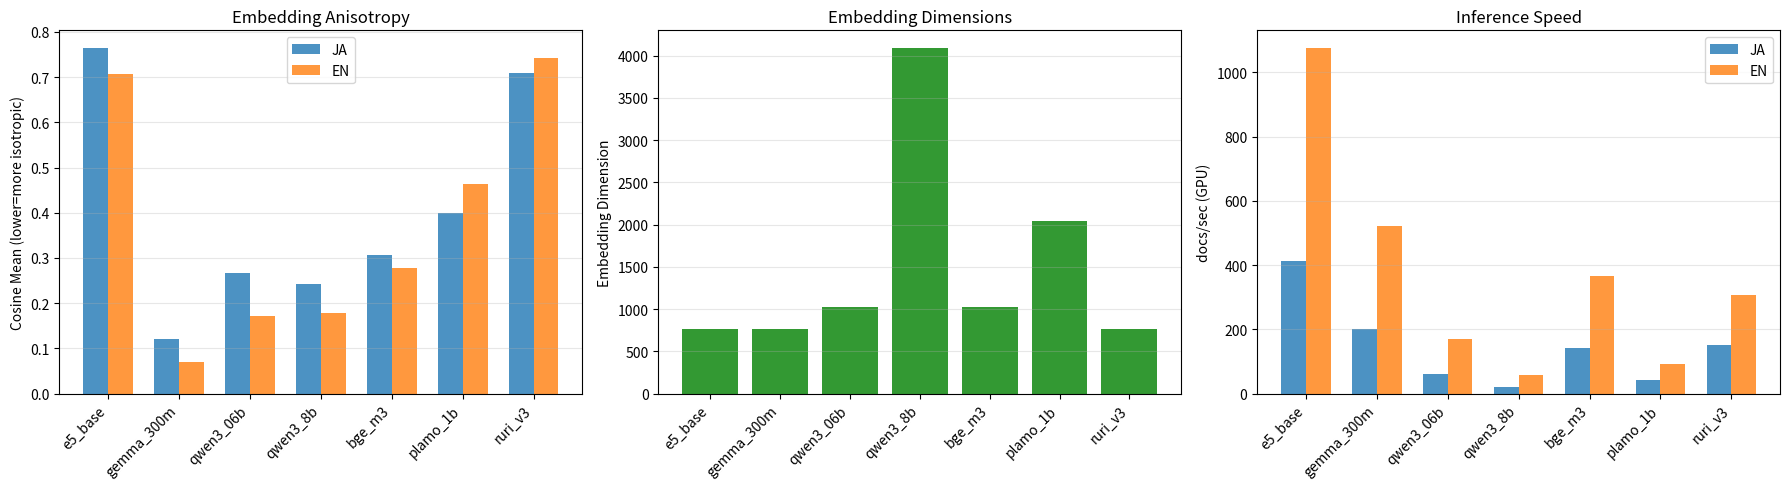

Saved: data/91_embedding_comparison.png


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. コサイン類似度平均（低いほど良い = 等方的）
models_ja = [r['model'] for r in all_results_ja]
cos_means_ja = [r['cos_mean'] for r in all_results_ja]
cos_means_en = [r['cos_mean'] for r in all_results_en]

x = np.arange(len(models_ja))
width = 0.35
axes[0].bar(x - width/2, cos_means_ja, width, label='JA', alpha=0.8)
axes[0].bar(x + width/2, cos_means_en, width, label='EN', alpha=0.8)
axes[0].set_ylabel('Cosine Mean (lower=more isotropic)')
axes[0].set_title('Embedding Anisotropy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_ja, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Embedding次元
dims = [r['dim'] for r in all_results_ja]
axes[1].bar(models_ja, dims, alpha=0.8, color='green')
axes[1].set_ylabel('Embedding Dimension')
axes[1].set_title('Embedding Dimensions')
axes[1].set_xticklabels(models_ja, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# 3. 推論速度（Noneを除外）
speed_valid = [r for r in speed_results if r['ja_docs_sec'] is not None]
speed_ja = [r['ja_docs_sec'] for r in speed_valid]
speed_en = [r['en_docs_sec'] for r in speed_valid]
speed_models = [r['model'] for r in speed_valid]
x2 = np.arange(len(speed_models))
axes[2].bar(x2 - width/2, speed_ja, width, label='JA', alpha=0.8)
axes[2].bar(x2 + width/2, speed_en, width, label='EN', alpha=0.8)
axes[2].set_ylabel('docs/sec (GPU)')
axes[2].set_title('Inference Speed')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(speed_models, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "91_embedding_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/91_embedding_comparison.png")

## 5. ITQ-LSH適性の簡易評価

各モデルのEmbeddingに対してITQ-LSHを訓練し、Hamming-Cosine Spearman相関を確認する。
これにより、どのモデルがITQ-LSHと相性が良いかを素早く判定できる。

In [15]:
import sys
sys.path.insert(0, '../src')
from itq_lsh import ITQLSH, hamming_distance_batch
from scipy.stats import spearmanr

def quick_itq_eval(embeddings: np.ndarray, model_name: str, n_pairs: int = 10000) -> dict:
    """ITQ-LSHのハッシュ品質を簡易評価"""
    dim = embeddings.shape[1]
    n_bits = min(128, dim)
    
    itq = ITQLSH(n_bits=n_bits, n_iterations=50, seed=42)
    itq.fit(embeddings)
    hashes = itq.transform(embeddings)
    
    # ランダムペアでSpearman相関
    rng = np.random.default_rng(42)
    n = len(embeddings)
    idx1 = rng.choice(n, n_pairs, replace=True)
    idx2 = rng.choice(n, n_pairs, replace=True)
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]
    
    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)
    ham_dists = np.sum(hashes[idx1] != hashes[idx2], axis=1)
    
    corr, pval = spearmanr(ham_dists, cos_sims)
    
    return {
        'model': model_name,
        'n_bits': n_bits,
        'spearman': corr,
        'pvalue': pval,
        'ham_mean': float(np.mean(ham_dists)),
        'ham_std': float(np.std(ham_dists)),
    }

print("ITQ-LSH ハッシュ品質評価 (Hamming-Cosine Spearman)")
print("="*60)

ITQ-LSH ハッシュ品質評価 (Hamming-Cosine Spearman)


In [16]:
# 保存済みEmbeddingを読み込んでITQ評価
itq_results_ja = []
itq_results_en = []

for key in loaded_models:
    ja_path = DATA_DIR / f"10k_{key}_ja_embeddings.npy"
    en_path = DATA_DIR / f"10k_{key}_en_embeddings.npy"

    emb = np.load(ja_path).astype(np.float32)
    result = quick_itq_eval(emb, key)
    itq_results_ja.append(result)
    print(f"{key} (JA): Spearman={result['spearman']:.4f}, bits={result['n_bits']}")

    emb = np.load(en_path).astype(np.float32)
    result = quick_itq_eval(emb, key)
    itq_results_en.append(result)
    print(f"{key} (EN): Spearman={result['spearman']:.4f}, bits={result['n_bits']}")
    print()

ITQ学習開始: samples=9990, dim=768, bits=128
  Centering完了: mean_norm=0.8749
  PCA完了: explained_variance=68.22%
  ITQ iteration 10: quantization_error=0.9428
  ITQ iteration 20: quantization_error=0.9424
  ITQ iteration 30: quantization_error=0.9423
  ITQ iteration 40: quantization_error=0.9422
  ITQ iteration 50: quantization_error=0.9421
ITQ学習完了
e5_base (JA): Spearman=-0.5814, bits=128
ITQ学習開始: samples=10000, dim=768, bits=128
  Centering完了: mean_norm=0.8404
  PCA完了: explained_variance=61.78%
  ITQ iteration 10: quantization_error=0.9399
  ITQ iteration 20: quantization_error=0.9396
  ITQ iteration 30: quantization_error=0.9394
  ITQ iteration 40: quantization_error=0.9393
  ITQ iteration 50: quantization_error=0.9393
ITQ学習完了
e5_base (EN): Spearman=-0.6045, bits=128

ITQ学習開始: samples=9990, dim=768, bits=128
  Centering完了: mean_norm=0.3483
  PCA完了: explained_variance=63.29%
  ITQ iteration 10: quantization_error=0.8949
  ITQ iteration 20: quantization_error=0.8942
  ITQ iteration 30: quan

In [17]:
print("\n" + "="*80)
print("ITQ-LSH品質: 日本語 (JA)")
print("="*80)
df_itq_ja = pd.DataFrame(itq_results_ja)
print(df_itq_ja.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(f"\n{'='*80}")
print("ITQ-LSH品質: 英語 (EN)")
print("="*80)
df_itq_en = pd.DataFrame(itq_results_en)
print(df_itq_en.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


ITQ-LSH品質: 日本語 (JA)
     model  n_bits  spearman  pvalue  ham_mean  ham_std
   e5_base     128   -0.5814  0.0000   64.0800   8.8108
gemma_300m     128   -0.6612  0.0000   64.0084   8.7343
 qwen3_06b     128   -0.6423  0.0000   64.0445   7.3275
  qwen3_8b     128   -0.6548  0.0000   64.0422   8.3479
    bge_m3     128   -0.6485  0.0000   64.0601   8.9940
  plamo_1b     128   -0.4899  0.0000   64.0111   8.2800
   ruri_v3     128   -0.4923  0.0000   63.8880   7.3291

ITQ-LSH品質: 英語 (EN)
     model  n_bits  spearman  pvalue  ham_mean  ham_std
   e5_base     128   -0.6045  0.0000   64.0054   6.5865
gemma_300m     128   -0.6424  0.0000   63.9832   6.4513
 qwen3_06b     128   -0.6363  0.0000   64.0612   6.5521
  qwen3_8b     128   -0.6155  0.0000   64.0938   6.9433
    bge_m3     128   -0.6211  0.0000   63.9567   6.7193
  plamo_1b     128   -0.5668  0.0000   64.0716   7.1849
   ruri_v3     128   -0.5867  0.0000   63.9493   6.5566


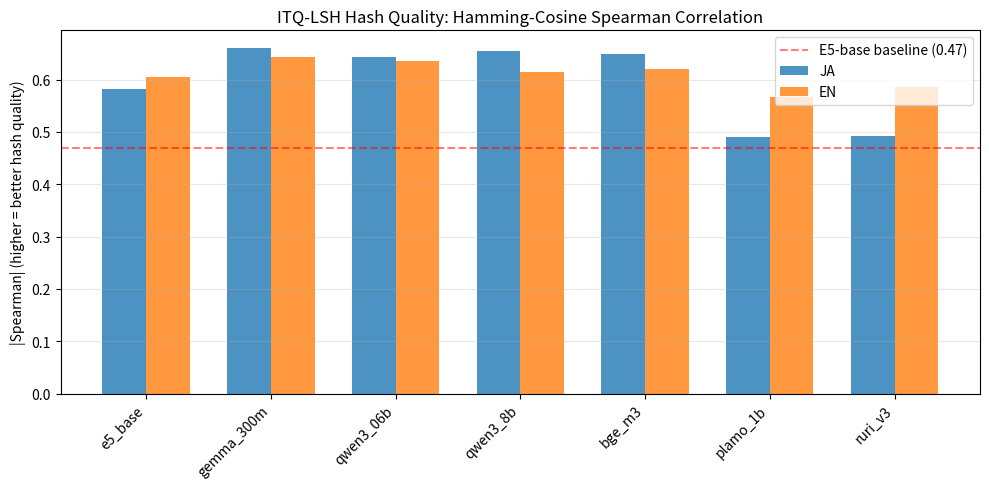

Saved: data/91_itq_spearman_comparison.png


In [18]:
# Spearman相関の比較グラフ
fig, ax = plt.subplots(figsize=(10, 5))

models = [r['model'] for r in itq_results_ja]
sp_ja = [abs(r['spearman']) for r in itq_results_ja]
sp_en = [abs(r['spearman']) for r in itq_results_en]

x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, sp_ja, width, label='JA', alpha=0.8)
ax.bar(x + width/2, sp_en, width, label='EN', alpha=0.8)
ax.set_ylabel('|Spearman| (higher = better hash quality)')
ax.set_title('ITQ-LSH Hash Quality: Hamming-Cosine Spearman Correlation')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.47, color='red', linestyle='--', alpha=0.5, label='E5-base baseline (0.47)')
ax.legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "91_itq_spearman_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/91_itq_spearman_comparison.png")

## 6. 総合サマリー

In [19]:
print("="*80)
print("実験91: 軽量Embeddingモデル性能比較 - 総合サマリー")
print("="*80)

# 総合テーブル作成
summary = []
for i, ms in enumerate(loaded_models):
    row = {
        'model': ms,
        'dim': all_results_ja[i]['dim'],
        'cos_mean_ja': all_results_ja[i]['cos_mean'],
        'cos_mean_en': all_results_en[i]['cos_mean'],
    }
    # ITQ結果を追加
    for r in itq_results_ja:
        if r['model'] == ms:
            row['spearman_ja'] = r['spearman']
    for r in itq_results_en:
        if r['model'] == ms:
            row['spearman_en'] = r['spearman']
    # 速度
    for r in speed_results:
        if r['model'] == ms:
            row['speed_ja'] = r['ja_docs_sec']
            row['speed_en'] = r['en_docs_sec']
    summary.append(row)

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n" + "="*80)
print("考察:")
print("- cos_mean が低いほど等方的（ITQ-LSHと相性が良い傾向）")
print("- |spearman| が大きいほどハッシュ品質が高い")
print("- 次の実験92では、上位モデルでRecall@10を詳細評価する")
print("="*80)

実験91: 軽量Embeddingモデル性能比較 - 総合サマリー
     model  dim  cos_mean_ja  cos_mean_en  spearman_ja  spearman_en  speed_ja  speed_en
   e5_base  768       0.7651       0.7061      -0.5814      -0.6045       413      1077
gemma_300m  768       0.1208       0.0703      -0.6612      -0.6424       201       523
 qwen3_06b 1024       0.2673       0.1717      -0.6423      -0.6363        61       170
  qwen3_8b 4096       0.2428       0.1790      -0.6548      -0.6155        20        58
    bge_m3 1024       0.3071       0.2770      -0.6485      -0.6211       141       365
  plamo_1b 2048       0.3983       0.4640      -0.4899      -0.5668        41        91
   ruri_v3  768       0.7100       0.7432      -0.4923      -0.5867       151       308

考察:
- cos_mean が低いほど等方的（ITQ-LSHと相性が良い傾向）
- |spearman| が大きいほどハッシュ品質が高い
- 次の実験92では、上位モデルでRecall@10を詳細評価する


## 7. まとめと考察

### Embedding品質（等方性: cos_mean）

| ランク | モデル | cos_mean JA | cos_mean EN | 評価 |
|--------|--------|-------------|-------------|------|
| 1 | EmbeddingGemma-300M | 0.121 | 0.070 | **最も等方的** — JA/EN両方で突出して低い |
| 2 | Qwen3-Embedding-8B | 0.243 | 0.179 | 高次元(4096d)だが等方性は良好 |
| 3 | Qwen3-Embedding-0.6B | 0.267 | 0.172 | 8Bとほぼ同等の等方性を0.6Bで実現 |
| 4 | BGE-M3 | 0.307 | 0.277 | 安定した中間的性能 |
| 5 | PLaMo-Embedding-1B | 0.398 | 0.464 | EN側の異方性がやや高い |
| 6 | Ruri-v3-310m | 0.710 | 0.743 | 日本語特化のため英語で異方性大 |
| 7 | multilingual-e5-base | 0.765 | 0.706 | ベースラインだが異方性が最も高い |

- e5-baseとRuri-v3はcos_mean 0.7超と**異方性が強い**。これはITQ-LSHのハッシュ品質に直接影響する。
- EmbeddingGemma-300Mは308Mパラメータで最も等方的な空間を生成しており、**小規模モデルとして際立つ**。

### ITQ-LSHハッシュ品質（|Spearman|）

| ランク | モデル | |Spearman| JA | |Spearman| EN | 評価 |
|--------|--------|--------------|--------------|------|
| 1 | EmbeddingGemma-300M | **0.661** | **0.642** | JA/EN共に最高品質 |
| 2 | Qwen3-Embedding-8B | 0.655 | 0.616 | Gemmaに迫るがコスト大 |
| 3 | BGE-M3 | 0.649 | 0.621 | 安定した高品質 |
| 4 | Qwen3-Embedding-0.6B | 0.642 | 0.636 | 0.6Bで8Bに匹敵するハッシュ品質 |
| 5 | e5-base | 0.581 | 0.605 | ベースライン |
| 6 | Ruri-v3-310m | 0.492 | 0.587 | 日本語でのハッシュ品質が低い |
| 7 | PLaMo-Embedding-1B | 0.490 | 0.567 | 2048dでも128bitへの圧縮損失が大きい |

- **EmbeddingGemma-300M、Qwen3-0.6B、BGE-M3が上位3強**（|Spearman| > 0.63）。
- e5-baseベースラインに対し、上位モデルは JA で +0.06〜0.08、EN で +0.02〜0.04 の改善。
- PLaMoとRuri-v3は1Bパラメータ・日本語特化にもかかわらず、ITQ-LSHとの相性は良くない。PLaMoは高次元(2048d)→128bitの情報損失、Ruri-v3は異方性の高さが原因と考えられる。

### 推論速度

| モデル | JA (docs/sec) | EN (docs/sec) | 備考 |
|--------|---------------|---------------|------|
| e5-base | 413 | 1077 | 最速（ベースライン） |
| EmbeddingGemma-300M | 201 | 523 | e5-baseの約半分 |
| Ruri-v3 | 151 | 308 | |
| BGE-M3 | 141 | 365 | |
| Qwen3-0.6B | 61 | 170 | LLMベースのため遅い |
| PLaMo-1B | 41 | 91 | |
| Qwen3-8B | 20 | 58 | 実用上はバッチ処理前提 |

- 日本語テキストは英語より2〜3倍遅い（トークン数が多いため）。

### 総合評価と次のステップ

**ITQ-LSHとの相性で選ぶベストモデル:**

1. **EmbeddingGemma-300M** — 等方性・ハッシュ品質ともに最高で、308Mと軽量。速度もまずまず。さらに**モデル自体が128bitバイナリ出力をサポート**しているため、ITQ-LSH vs モデルネイティブバイナリの比較実験が可能。
2. **Qwen3-Embedding-0.6B** — ハッシュ品質はGemmaに次ぐ水準で、8Bと遜色ない性能を0.6Bで実現。ただし速度はやや遅い。
3. **BGE-M3** — 多言語対応で安定した品質。速度と品質のバランスが良い。

**次の実験（実験92以降）:**
- EmbeddingGemma-300Mを中心に **ITQ-LSH vs ネイティブ128bitバイナリ** の Recall@10 比較
- 上位モデルでの **Pivot戦略の効果検証**
- 有望モデルの **ONNX化**による推論高速化の検討